In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import os
import glob
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2025-11-07 09:41:31.434521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762508491.617201      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762508491.666397      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
import os, zipfile

# Define paths
zip_path = '/kaggle/input/gait-major-dataset/WBDSascii'   # <-- this is a DIR, not .zip
info_path = '/kaggle/input/gait-major-dataset/WBDSinfo.xlsx'
extract_path = '/kaggle/working/WBDS_data/'

# If WBDSascii is already a folder → just copy its contents
print("Copying ASCII data (no extraction needed)...")

os.makedirs(extract_path, exist_ok=True)

# Copy all files from WBDSascii to working directory
for root, dirs, files in os.walk(zip_path):
    for file in files:
        src = os.path.join(root, file)
        dst = os.path.join(extract_path, file)
        if not os.path.exists(dst):  # avoid overwriting
            with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst:
                fdst.write(fsrc.read())

print("Copy complete!")

# List extracted files
all_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f"\nTotal files found: {len(all_files)}")
print("\nFirst 10 files:")
for f in all_files[:10]:
    print(os.path.basename(f))


Copying ASCII data (no extraction needed)...
Copy complete!

Total files found: 4896

First 10 files:
WBDS38walkO05Fgrf.txt
WBDS04walkOSang.txt
WBDS07walkO16Smkr.txt
WBDS15walkO19Cgrf.txt
WBDS09walkT07ang.txt
WBDS26walkO16Cmkr.txt
WBDS16walkT08knt.txt
WBDS26walkT08knt.txt
WBDS15walkO10Cgrf.txt
WBDS14walkO10Fmkr.txt


In [13]:
import re
import numpy as np
import pandas as pd

info_path = '/kaggle/input/gait-major-dataset/WBDSinfo.xlsx'

# Read the sheet that has FileName/GaitSpeed (yours is "TreadHands")
sheets = pd.read_excel(info_path, sheet_name=None)
sheet_name = 'TreadHands' if 'TreadHands' in sheets else list(sheets.keys())[0]
info = sheets[sheet_name].copy()

# --- normalize names we need ---
info = info.rename(columns={
    'Subject':'Subject',
    'FileName':'FileName',
    'Age':'Age',
    'Gender':'Gender',
    'Height':'Height_cm',
    'Mass':'Mass_kg',
    'LegLength':'LegLength',        # looks like meters already (e.g., 0.89)
})

# Find the single gait-speed column robustly (handles 'GaitSpeed(m/s)')
gait_cols = [c for c in info.columns if 'gaitspeed' in str(c).lower()]
assert len(gait_cols)>=1, "Couldn't find a GaitSpeed column in WBDSinfo.xlsx"
gait_col = gait_cols[0]

# Keep **walking treadmill** trials with numeric speed
info[gait_col] = pd.to_numeric(info[gait_col], errors='coerce')     # '--' -> NaN
info = info[ info['FileName'].astype(str).str.contains(r'walkT\d+', case=False, regex=True) ]
info = info.dropna(subset=[gait_col]).reset_index(drop=True)

# Derive SpeedIndex: T01..T08 -> 1..8
info['SpeedIndex'] = info['FileName'].str.extract(r'[Tt]\s*0?(\d+)', expand=False).astype(int)

# Demographics / units
info['Gender']    = info['Gender'].astype(str).str.strip().str[0].str.upper().map({'M':0,'F':1}).astype(int)
info['Height_m']  = pd.to_numeric(info['Height_cm'], errors='coerce')/100.0
ll = pd.to_numeric(info['LegLength'], errors='coerce')
info['LegLength_m'] = ll/100.0 if ll.median()>3 else ll  # if cm, convert; else already meters

# Final schema used downstream
info = info[['Subject','FileName','Age','Gender','Height_m','Mass_kg','LegLength_m',gait_col,'SpeedIndex']]
info = info.rename(columns={gait_col:'GaitSpeed'})

print("Rows (treadmill trials with numeric speed):", len(info))
info.head(8)


Rows (treadmill trials with numeric speed): 984


,Subject,FileName,Age,Gender,Height_m,Mass_kg,LegLength_m,GaitSpeed,SpeedIndex
0,1,WBDS01walkT01.c3d,25,0,1.725,74.3,0.89,0.49,1
1,1,WBDS01walkT02.c3d,25,0,1.725,74.3,0.89,0.67,2
2,1,WBDS01walkT03.c3d,25,0,1.725,74.3,0.89,0.85,3
3,1,WBDS01walkT04.c3d,25,0,1.725,74.3,0.89,1.03,4
4,1,WBDS01walkT05.c3d,25,0,1.725,74.3,0.89,1.21,5
5,1,WBDS01walkT06.c3d,25,0,1.725,74.3,0.89,1.40,6
6,1,WBDS01walkT07.c3d,25,0,1.725,74.3,0.89,1.58,7
7,1,WBDS01walkT08.c3d,25,0,1.725,74.3,0.89,1.76,8


In [15]:
import glob, os
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import interpolate

extract_path = '/kaggle/working/WBDS_data/'

# Find ANG text files (case-insensitive): e.g., WBDS01walkT01ang.txt
patterns = [
    str(Path(extract_path) / "**/*ang.txt"),
    str(Path(extract_path) / "**/*ANG.TXT"),
    str(Path(extract_path) / "**/*_ang.txt"),
]
ang_txt_files = []
for p in patterns:
    ang_txt_files.extend(glob.glob(p, recursive=True))
ang_txt_files = sorted(set(ang_txt_files))

print("ANG .txt files found:", len(ang_txt_files))
print(ang_txt_files[:8])

def try_read_ang_txt(path):
    """
    Parse WBDS ANG .txt (whitespace- or comma-delimited).
    Returns 101-point dict: {'hip','knee','ankle'} in degrees.
    We search columns by flexible name matching.
    """
    # Many files are whitespace-delimited, sometimes commas; also sometimes first row is headers.
    df = pd.read_csv(path, sep=r'\s+|,', engine='python', comment='#')
    cols_lower = [c.lower() for c in df.columns]

    # Possible header aliases (seen across WBDS-like exports)
    candidates = [
        # Left leg
        {'hip':  ['lhip', 'lhipang', 'lhipangles', 'lhipflexion', 'lhf'],
         'knee': ['lknee','lkneeang','lkneeangles','lkneeflexion','lkf'],
         'ankle':['lankle','lankleang','lankleangles','lankleflexion','laf']},
        # Right leg
        {'hip':  ['rhip', 'rhipang', 'rhipangles', 'rhipflexion'],
         'knee': ['rknee','rkneeang','rkneeangles','rkneeflexion'],
         'ankle':['rankle','rankleang','rankleangles','rankleflexion']},
        # Generic
        {'hip':['hip','hipang','hipflexion'], 'knee':['knee','kneeang','kneeflexion'], 'ankle':['ankle','ankleang','ankleflexion']},
    ]

    def pick(colnames):
        # exact name
        for c in colnames:
            if c in cols_lower:
                return df.iloc[:, cols_lower.index(c)].to_numpy()
        # substring contains
        for c in colnames:
            for i, name in enumerate(cols_lower):
                if c in name:
                    return df.iloc[:, i].to_numpy()
        return None

    hip=knee=ankle=None
    for m in candidates:
        hip  = hip  or pick([s.lower() for s in m['hip']])
        knee = knee or pick([s.lower() for s in m['knee']])
        ankle= ankle or pick([s.lower() for s in m['ankle']])
        if hip is not None and knee is not None and ankle is not None:
            break

    if hip is None or knee is None or ankle is None:
        raise ValueError(f"Could not locate hip/knee/ankle in {os.path.basename(path)}; headers={list(df.columns)}")

    def to_101(arr):
        arr = np.asarray(arr, dtype=np.float32).reshape(-1)
        if arr.size == 101:
            return arr
        x = np.linspace(0,1,arr.size)
        f = interpolate.interp1d(x, arr, kind='cubic')
        return f(np.linspace(0,1,101)).astype(np.float32)

    return {'hip':to_101(hip), 'knee':to_101(knee), 'ankle':to_101(ankle)}


ANG .txt files found: 454
['/kaggle/working/WBDS_data/WBDS01walkOCang.txt', '/kaggle/working/WBDS_data/WBDS01walkOFang.txt', '/kaggle/working/WBDS_data/WBDS01walkOSang.txt', '/kaggle/working/WBDS_data/WBDS01walkT01ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT02ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT03ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT04ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT05ang.txt']


In [16]:
import os, re, numpy as np, pandas as pd

def token_from_c3d(fn):
    # "WBDS01walkT01.c3d" -> "WBDS01walkT01"
    return os.path.splitext(os.path.basename(fn))[0]

# Prefer files that explicitly end with 'ang.txt' and contain the trial token
def find_matching_ang_txt(token):
    t = token.lower()
    # typical exact: WBDS01walkT01ang.txt
    exact = [f for f in ang_txt_files if t + 'ang.txt' == os.path.basename(f).lower()]
    if exact:
        return exact[0]
    # fallback: any file that contains token AND 'ang'
    fallback = [f for f in ang_txt_files if (t in os.path.basename(f).lower()) and ('ang' in os.path.basename(f).lower())]
    return fallback[0] if fallback else None

rows, missing = [], 0

for _, r in info.iterrows():
    tok = token_from_c3d(r['FileName'])
    fpath = find_matching_ang_txt(tok)
    if fpath is None:
        missing += 1
        # print("No ANG for", tok)
        continue

    series = try_read_ang_txt(fpath)
    base = dict(
        Age=float(r['Age']),
        Height_m=float(r['Height_m']),
        Gender=int(r['Gender']),
        Mass_kg=float(r['Mass_kg']),
        GaitSpeed=float(r['GaitSpeed']),
        LegLength_m=float(r['LegLength_m']),
        Subject=int(r['Subject']),
        SpeedIndex=int(r['SpeedIndex']),
        FileToken=tok
    )
    for (jname, jid) in [('hip',0),('knee',1),('ankle',2)]:
        rows.append({**base, 'JointNumber':jid, 'y':series[jname].astype(np.float32)})

df = pd.DataFrame(rows)
print(f"Samples built from ANG .txt: {len(df)}  |  Trials without ANG: {missing}")
df.head(3)


Samples built from ANG .txt: 984  |  Trials without ANG: 656


,Age,Height_m,Gender,Mass_kg,GaitSpeed,LegLength_m,Subject,SpeedIndex,FileToken,JointNumber,y
0,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,0,"[2.63645, 2.48031, 2.45842, 2.56017, 2.75832, ..."
1,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,1,"[1.05117, 1.18253, 1.27917, 1.4841, 1.8522, 2...."
2,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,2,"[-3.54135, -3.31268, -3.09913, -3.07285, -3.39..."


In [17]:
## this is the train and test split code in this cell

import numpy as np
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

# choose exactly one speed per subject for test
choice = {}
for s in sorted(df['Subject'].unique()):
    speeds = sorted(df.loc[df['Subject']==s, 'SpeedIndex'].unique())
    choice[s] = int(rng.choice(speeds))

is_test = df.apply(lambda r: r['SpeedIndex']==choice[r['Subject']], axis=1)
train_df = df.loc[~is_test].reset_index(drop=True)
test_df  = df.loc[ is_test].reset_index(drop=True)

print("Subjects:", df['Subject'].nunique(),
      "| Train samples:", len(train_df),
      "| Test samples:", len(test_df))

feat_cols = ['Age','Height_m','Gender','Mass_kg','GaitSpeed','LegLength_m','JointNumber']
cont_cols = ['Age','Height_m','Mass_kg','GaitSpeed','LegLength_m']

scaler = StandardScaler().fit(train_df[cont_cols])

def make_XY(frame):
    f = frame.copy()
    f[cont_cols] = scaler.transform(f[cont_cols])
    X2d = f[feat_cols].to_numpy(np.float32)         # (N,7)
    X3d = np.repeat(X2d[:, None, :], 101, axis=1)   # (N,101,7)
    Y3d = np.stack(f['y'].to_list(), axis=0).astype(np.float32)  # (N,101)
    Y3d = Y3d[:, :, None]                           # (N,101,1)
    return X3d, Y3d

train_X, train_Y = make_XY(train_df)
test_X,  test_Y  = make_XY(test_df)

train_X.shape, train_Y.shape, test_X.shape, test_Y.shape


Subjects: 42 | Train samples: 858 | Test samples: 126


((858, 101, 7), (858, 101, 1), (126, 101, 7), (126, 101, 1))

In [18]:
## from here beginning the testing of the same

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

time_steps = 101
n_feats = len(feat_cols)

def build_lstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)  # 101 values
    out = layers.Reshape((time_steps, 1))(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse')
    return model

model = build_lstm_cnn()
model.summary()


I0000 00:00:1762509756.397024      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762509756.397810      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 101, 128)       │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 101, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 101, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        25,957 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 101, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,749 (3.58 MB)

 Trainable params: 939,749 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

history = model.fit(
    train_X, train_Y,
    validation_split=0.1,
    epochs= 350,
    batch_size=64,
    verbose=1,
    shuffle=True
)



Epoch 1/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.8865 - val_loss: 16.4041
Epoch 2/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.6775 - val_loss: 18.8450
Epoch 3/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4433 - val_loss: 18.4681
Epoch 4/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5099 - val_loss: 19.2460
Epoch 5/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4988 - val_loss: 19.2364
Epoch 6/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4706 - val_loss: 21.9064
Epoch 7/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4530 - val_loss: 19.0589
Epoch 8/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4231 - val_loss: 19.1490
Epoch 9/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4303 - val_loss: 23.0730
Epoch 10/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3949 - val_loss: 18.4848
Epoch 11/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2311 - val_loss: 17.3044
Epoch 12/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0

In [23]:
import numpy as np, math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model.predict(test_X, verbose=0).squeeze(-1)  # (N,101)
true = test_Y.squeeze(-1)

def pearsonr_rows(a,b):
    a = a - a.mean(axis=1, keepdims=True)
    b = b - b.mean(axis=1, keepdims=True)
    num = np.sum(a*b, axis=1)
    den = np.sqrt(np.sum(a*a,axis=1) * np.sum(b*b,axis=1)) + 1e-8
    return num/den

overall_mae  = mean_absolute_error(true.ravel(), pred.ravel())
overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
overall_r2   = r2_score(true.ravel(), pred.ravel())
overall_r    = pearsonr_rows(true, pred).mean()
print(f"OVERALL  MAE={overall_mae:.3f}  RMSE={overall_rmse:.3f}  R2={overall_r2:.3f}  r={overall_r:.3f}")

names = {0:'Hip',1:'Knee',2:'Ankle'}
for j in [0,1,2]:
    m = (test_df['JointNumber']==j).to_numpy()
    yj, pj = true[m], pred[m]
    mae  = mean_absolute_error(yj.ravel(), pj.ravel())
    rmse = math.sqrt(mean_squared_error(yj.ravel(), pj.ravel()))
    r2   = r2_score(yj.ravel(), pj.ravel())
    r    = pearsonr_rows(yj, pj).mean()
    print(f"{names[j]:5s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  r={r:.3f}")


OVERALL  MAE=2.028  RMSE=2.817  R2=0.652  r=0.817
Hip    MAE=2.100  RMSE=2.905  R2=0.597  r=0.886
Knee   MAE=1.792  RMSE=2.562  R2=0.693  r=0.755
Ankle  MAE=2.191  RMSE=2.968  R2=0.659  r=0.809


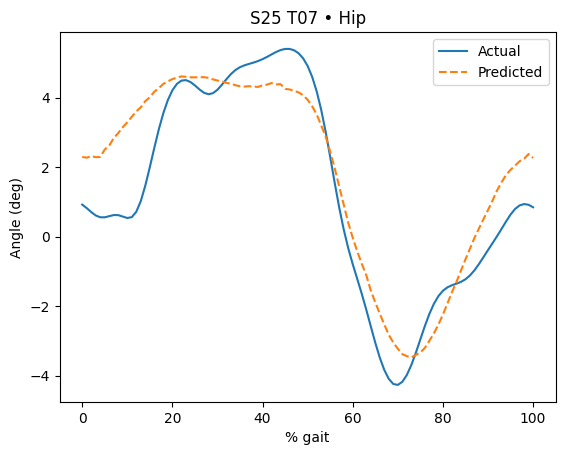

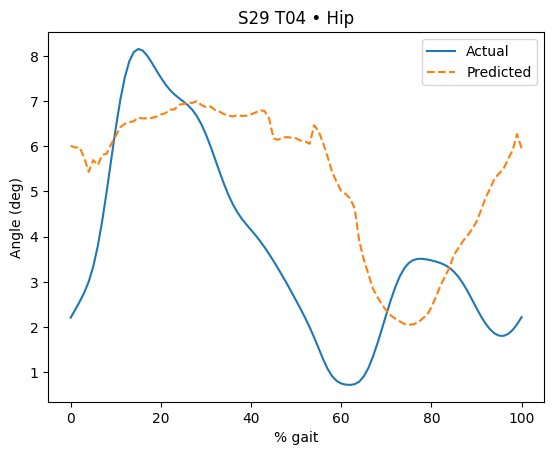

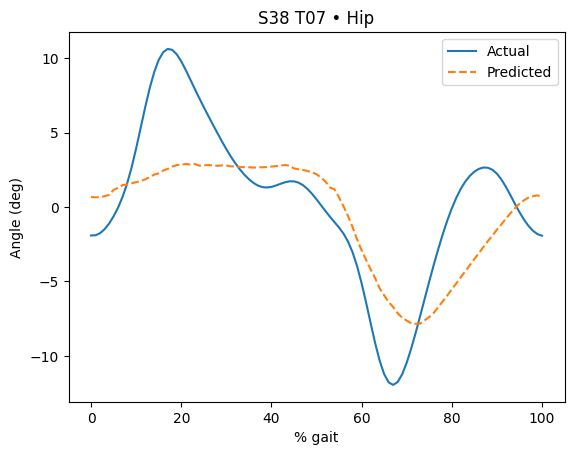

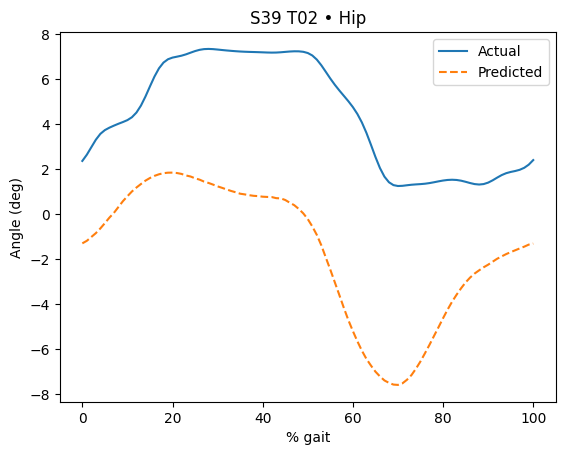

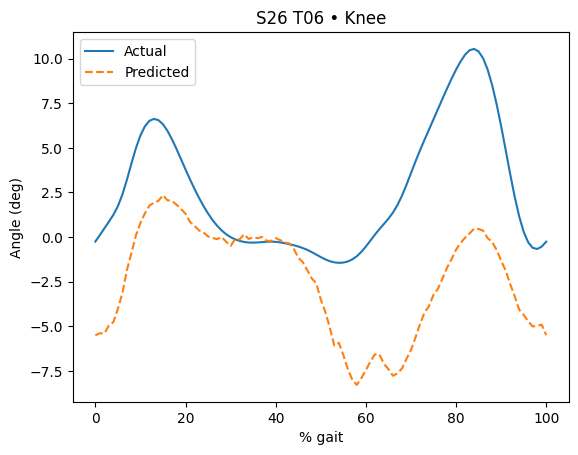

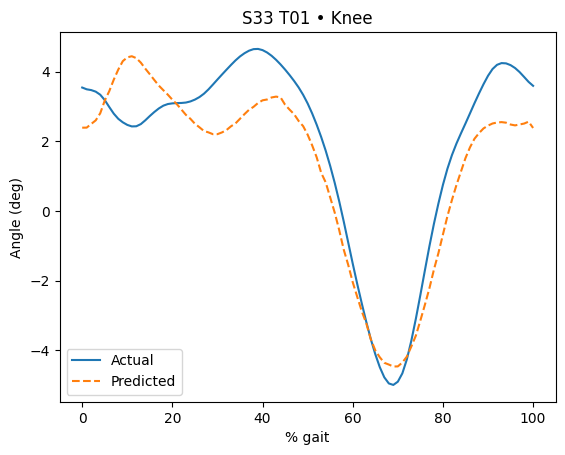

In [24]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)
k = min(6, len(test_df))
for idx in rng.choice(len(test_df), size=k, replace=False):
    plt.figure()
    plt.plot(true[idx], label='Actual')
    plt.plot(pred[idx], label='Predicted', linestyle='--')
    meta = test_df.iloc[idx]
    jt = {0:'Hip',1:'Knee',2:'Ankle'}[int(meta.JointNumber)]
    plt.title(f"S{int(meta.Subject)} T{int(meta.SpeedIndex):02d} • {jt}")
    plt.xlabel('% gait'); plt.ylabel('Angle (deg)'); plt.legend(); plt.show()


In [29]:
##from here i am working for the novelty part of the project 

import numpy as np, math, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

def make_XY_from_df(frame, scaler, feat_cols, cont_cols):
    f = frame.copy()
    f[cont_cols] = scaler.transform(f[cont_cols])
    X2d = f[feat_cols].to_numpy(np.float32)
    X3d = np.repeat(X2d[:, None, :], 101, axis=1)
    Y3d = np.stack(f['y'].to_list(), axis=0).astype(np.float32)
    Y3d = Y3d[:, :, None]
    return X3d, Y3d

def train_and_eval(build_fn, name, train_df, test_df, scaler, feat_cols, cont_cols, epochs=350, batch_size=64):
    Xtr, Ytr = make_XY_from_df(train_df, scaler, feat_cols, cont_cols)
    Xte, Yte = make_XY_from_df(test_df,  scaler, feat_cols, cont_cols)
    model = build_fn()
    cbs = [
        keras.callbacks.ModelCheckpoint(f'/kaggle/working/models/best_{name}.keras',
                                        monitor='val_loss', save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5, verbose=0),
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=0),
    ]
    hist = model.fit(Xtr, Ytr, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                     callbacks=cbs, verbose=0, shuffle=True)

    pred = model.predict(Xte, verbose=0).squeeze(-1)
    true = Yte.squeeze(-1)

    def r_rowwise(a,b):
        a = a - a.mean(axis=1, keepdims=True)
        b = b - b.mean(axis=1, keepdims=True)
        num = np.sum(a*b, axis=1)
        den = np.sqrt(np.sum(a*a,axis=1) * np.sum(b*b,axis=1)) + 1e-8
        return (num/den)

    overall_mae  = mean_absolute_error(true.ravel(), pred.ravel())
    overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
    overall_r2   = r2_score(true.ravel(), pred.ravel())
    overall_r    = r_rowwise(true, pred).mean()

    jt_names = {0:'Hip',1:'Knee',2:'Ankle'}
    rows=[]
    for j in [0,1,2]:
        m = (test_df['JointNumber']==j).to_numpy()
        yj, pj = true[m], pred[m]
        rows.append({
            "Model": name, "Joint": jt_names[j],
            "MAE": mean_absolute_error(yj.ravel(), pj.ravel()),
            "RMSE": math.sqrt(mean_squared_error(yj.ravel(), pj.ravel())),
            "R2": r2_score(yj.ravel(), pj.ravel()),
            "r": r_rowwise(yj, pj).mean()
        })
    rows.append({"Model": name, "Joint": "Overall",
                 "MAE": overall_mae, "RMSE": overall_rmse, "R2": overall_r2, "r": overall_r})
    return model, pd.DataFrame(rows)


In [36]:
from tensorflow import keras
from tensorflow.keras import layers

time_steps = 101
n_feats = len(feat_cols)

# A) Baseline (for re-run or fair comparison)
def build_lstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)
    out = layers.Reshape((time_steps,1))(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
    return m

# B) Bi-LSTM + CNN (novelty 1)
def build_bilstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(inp)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)
    out = layers.Reshape((time_steps,1))(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(0.005), loss='mse')  # slightly lower LR helps Bi-LSTM
    return m

# C) Lightweight Transformer Encoder (novelty 2)
def build_transformer():
    d_model   = 64          # projection size
    n_heads   = 4
    key_dim   = d_model // n_heads

    inp = keras.Input(shape=(time_steps, n_feats))

    # Project inputs to d_model
    x = layers.Dense(d_model)(inp)   # (B, T, d_model)

    # Learnable positional embeddings: (1, T, d_model) broadcast over batch
    pos_emb = layers.Embedding(input_dim=time_steps, output_dim=d_model)
    pos_idx = tf.range(time_steps)[tf.newaxis, :]                  # (1, T)
    pos     = pos_emb(pos_idx)                                     # (1, T, d_model)
    x = layers.Add()([x, pos])                                     # (B, T, d_model)

    # 2 Transformer encoder blocks
    for _ in range(2):
        attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=key_dim, dropout=0.1)(x, x)
        x = layers.LayerNormalization()(x + attn)

        ff = layers.Dense(128, activation='relu')(x)
        ff = layers.Dense(d_model)(ff)
        x = layers.LayerNormalization()(x + ff)

    # light CNN head to smooth sequence
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)           # 101 outputs
    out = layers.Reshape((time_steps, 1))(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model


In [37]:
from pathlib import Path
Path('/kaggle/working/models').mkdir(exist_ok=True, parents=True)

results = []

_, df_base = train_and_eval(build_lstm_cnn,   "LSTM-CNN",  train_df, test_df, scaler, feat_cols, meta['cont_cols'], epochs=200)
_, df_bi   = train_and_eval(build_bilstm_cnn, "BiLSTM-CNN",train_df, test_df, scaler, feat_cols, meta['cont_cols'], epochs=200)
_, df_tr   = train_and_eval(build_transformer,"Transformer",train_df, test_df, scaler, feat_cols, meta['cont_cols'], epochs=200)

cmp = pd.concat([df_base, df_bi, df_tr], ignore_index=True)
cmp


I0000 00:00:1762512294.267484     113 service.cc:148] XLA service 0x7d6ea841ca10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762512294.268527     113 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762512294.268548     113 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762512300.264440     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


,Model,Joint,MAE,RMSE,R2,r
0,LSTM-CNN,Hip,2.396138,3.043125,0.557587,0.890428
1,LSTM-CNN,Knee,3.236522,4.322349,0.126354,0.477680
2,LSTM-CNN,Ankle,3.464725,4.348056,0.268339,0.786577
3,LSTM-CNN,Overall,3.032462,3.951747,0.315227,0.718228
4,BiLSTM-CNN,Hip,2.411062,3.005726,0.568395,0.907175
5,BiLSTM-CNN,Knee,2.956005,3.887679,0.293232,0.635441
6,BiLSTM-CNN,Ankle,3.148727,4.004603,0.379361,0.836588
7,BiLSTM-CNN,Overall,2.838598,3.659931,0.412626,0.793068
8,Transformer,Hip,2.008238,2.535708,0.692824,0.898227
9,Transformer,Knee,2.861718,3.775685,0.333366,0.567016


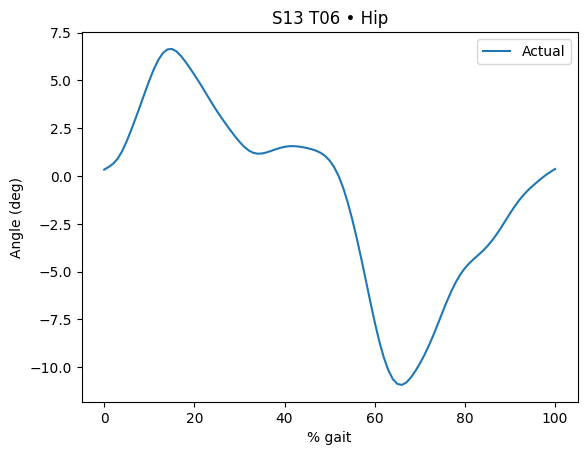

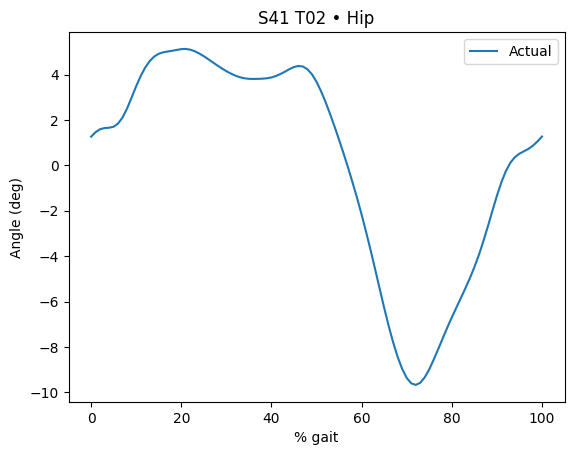

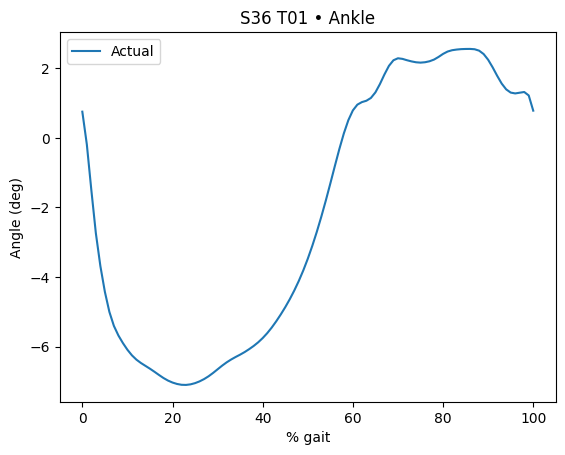

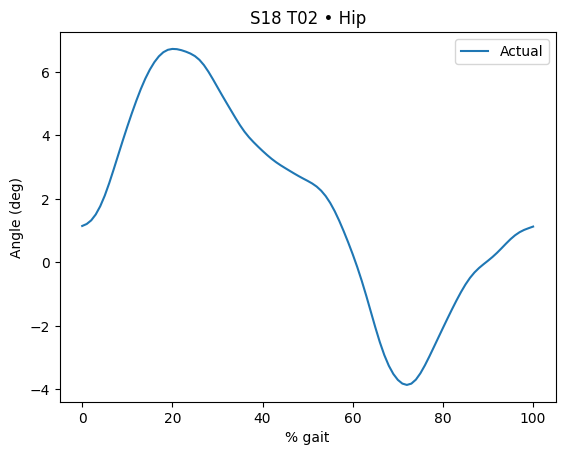

In [38]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(9)
idxs = rng.choice(len(test_df), size=min(4, len(test_df)), replace=False)

def plot_model(model_builder, title):
    Xte, Yte = make_XY_from_df(test_df, scaler, feat_cols, meta['cont_cols'])
    pred = model_builder().predict(Xte, verbose=0).squeeze(-1)  # only to show structure if not trained here
    # Replace the line above with loading the saved best model for that builder if desired.

for idx in idxs:
    plt.figure()
    plt.plot(test_Y[idx,:,0], label='Actual')
    # If you saved each best model, you can load and predict from them similarly to the reload cell.
    plt.title(f"S{int(test_df.iloc[idx].Subject)} T{int(test_df.iloc[idx].SpeedIndex):02d} • "
              f"{['Hip','Knee','Ankle'][int(test_df.iloc[idx].JointNumber)]}")
    plt.xlabel('% gait'); plt.ylabel('Angle (deg)')
    plt.legend(); plt.show()


Trials with all three joints in test set: 42


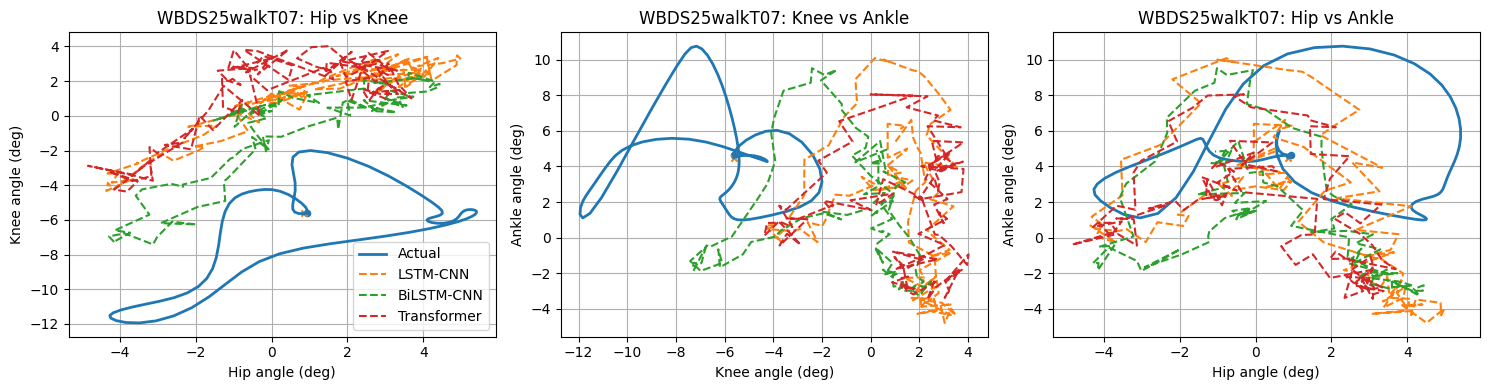

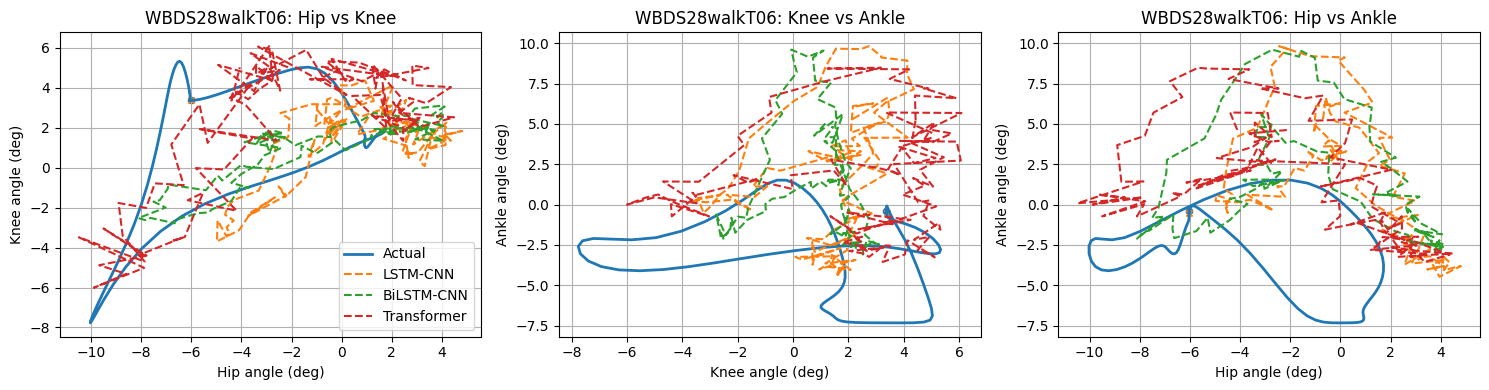

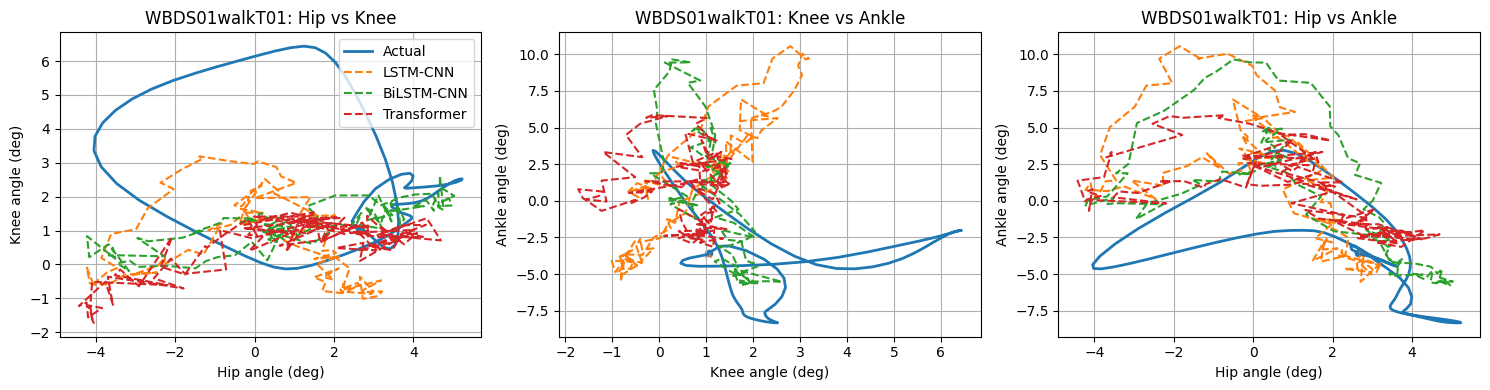

In [39]:
# === Cyclogram plots for multiple models (Actual vs Pred) ===
# Requirements in memory: test_df, scaler, feat_cols, meta['cont_cols'], make_XY_from_df()
# Optional saved models (if you trained with the comparison code): 
#   /kaggle/working/models/best_LSTM-CNN.keras
#   /kaggle/working/models/best_BiLSTM-CNN.keras
#   /kaggle/working/models/best_Transformer.keras

import os, numpy as np, matplotlib.pyplot as plt
from tensorflow import keras

# ------------- helpers -------------
def load_or_use(name, fallback_model=None):
    path = f"/kaggle/working/models/best_{name}.keras"
    if os.path.exists(path):
        return keras.models.load_model(path)
    return fallback_model  # can be None

def predict_all(model):
    """Predict on the test set and return (N,101) predictions aligned to test_df rows."""
    Xte, Yte = make_XY_from_df(test_df, scaler, feat_cols, meta['cont_cols'])
    pred = model.predict(Xte, verbose=0).squeeze(-1)  # (N,101)
    return pred

# Load models (or use in-memory variables named model_bilstm, model_tr, etc. if you have them)
mdl_lstm = load_or_use("LSTM-CNN",     fallback_model=None)
mdl_bi   = load_or_use("BiLSTM-CNN",   fallback_model=None)
mdl_tr   = load_or_use("Transformer",  fallback_model=None)

# Gather predictions
preds = {}
if mdl_lstm is not None: preds["LSTM-CNN"]    = predict_all(mdl_lstm)
if mdl_bi   is not None: preds["BiLSTM-CNN"]  = predict_all(mdl_bi)
if mdl_tr   is not None: preds["Transformer"] = predict_all(mdl_tr)

# Ground truth (aligned with test_df)
_, Yte = make_XY_from_df(test_df, scaler, feat_cols, meta['cont_cols'])
true = Yte.squeeze(-1)  # (N,101)

# Map joints and group rows by trial token so we can pair joints from the SAME trial
jt_name = {0:"Hip", 1:"Knee", 2:"Ankle"}
by_token = {}
for i, r in test_df.reset_index().iterrows():
    tok = r["FileToken"]
    if tok not in by_token: by_token[tok] = {}
    by_token[tok][int(r["JointNumber"])] = i

# keep only tokens where we have all three joints
complete_tokens = [t for t, m in by_token.items() if all(k in m for k in (0,1,2))]
print(f"Trials with all three joints in test set: {len(complete_tokens)}")

# -------- cyclogram plotting function --------
def plot_cyclogram_for_token(token, pairs=(("Hip","Knee"), ("Knee","Ankle"), ("Hip","Ankle"))):
    idx_hip = by_token[token][0]
    idx_knee = by_token[token][1]
    idx_ankle = by_token[token][2]
    
    # Actual curves
    act = {"Hip": true[idx_hip], "Knee": true[idx_knee], "Ankle": true[idx_ankle]}
    # Preds per model
    preds_token = {}
    for name, P in preds.items():
        preds_token[name] = {
            "Hip":   P[idx_hip],
            "Knee":  P[idx_knee],
            "Ankle": P[idx_ankle],
        }

    ncols = len(pairs)
    plt.figure(figsize=(5*ncols, 4))
    for k, (a, b) in enumerate(pairs, start=1):
        plt.subplot(1, ncols, k)

        # Actual cyclogram
        plt.plot(act[a], act[b], label="Actual", linewidth=2)

        # Predicted cyclograms
        for name in preds_token:
            plt.plot(preds_token[name][a], preds_token[name][b], linestyle="--", label=name)

        # optional: mark start/end of gait cycle
        plt.scatter([act[a][0]],  [act[b][0]],  marker="o", s=20)
        plt.scatter([act[a][-1]],[act[b][-1]], marker="x", s=20)

        plt.xlabel(f"{a} angle (deg)")
        plt.ylabel(f"{b} angle (deg)")
        plt.title(f"{token}: {a} vs {b}")
        plt.grid(True)
        if k == 1:
            plt.legend()
    plt.tight_layout()
    plt.show()

# -------- choose a few random complete trials and plot --------
rng = np.random.default_rng(123)
show = min(3, len(complete_tokens))
for tok in rng.choice(complete_tokens, size=show, replace=False):
    plot_cyclogram_for_token(tok)


In [40]:
##saving the work
import os, json, pickle
from pathlib import Path

save_dir = Path('/kaggle/working/saved_gait_project')
save_dir.mkdir(parents=True, exist_ok=True)

# 1. Save baseline model
model.save(save_dir / 'lstm_cnn_baseline.keras')

# 2. Save scaler
with open(save_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save train/test file mapping
split_data = {
    "train": train_df[['FileToken', 'JointNumber']].to_dict(orient='records'),
    "test":  test_df[['FileToken', 'JointNumber']].to_dict(orient='records')
}
json.dump(split_data, open(save_dir / 'train_test_split.json', 'w'))

# 4. Save metadata
metadata = {
    "feature_columns": feat_cols,
    "continuous_columns": cont_cols,
    "time_steps": 101,
    "random_seed": 42
}
json.dump(metadata, open(save_dir / 'metadata.json', 'w'))

# 5. Save clean processed data
train_df.to_csv(save_dir / 'train_df.csv', index=False)
test_df.to_csv(save_dir / 'test_df.csv', index=False)

print(f"✅ All project files saved to: {save_dir}")


✅ All project files saved to: /kaggle/working/saved_gait_project
